X shape: torch.Size([60, 1])
y shape: torch.Size([60, 60])

Initial parameters:
w: tensor([[1.]])
b: tensor([1.])
Iteration 5, Loss: 3.118382
Iteration 10, Loss: 3.111671
Iteration 15, Loss: 3.111972
Iteration 20, Loss: 3.111642
Iteration 25, Loss: 3.111690

Final Results:
True w: 1.000000
Learned w: 0.001035
Error in w: 0.998965

True b: -1.000000
Learned b: -0.980257
Error in b: 0.019743


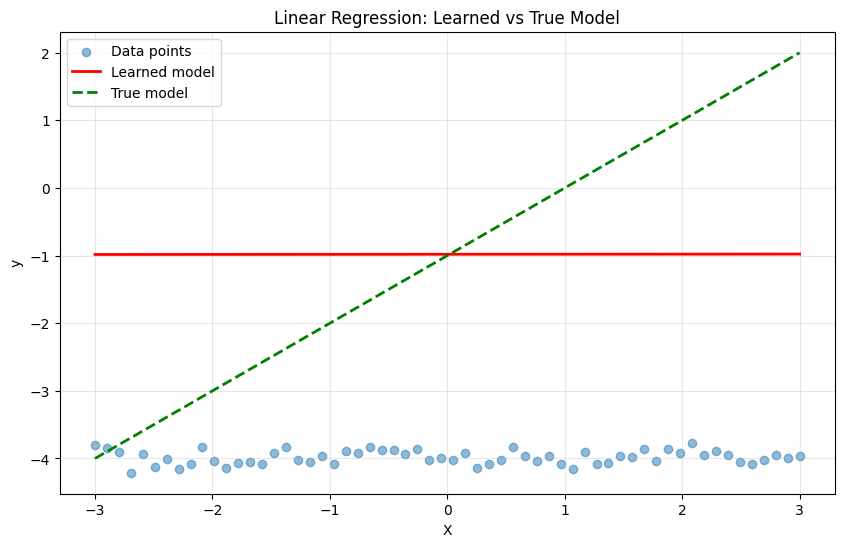

In [4]:
import torch
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

# Generate dataset
# X from -3 to 3, 60 samples
X = torch.linspace(-3, 3, 60).reshape(-1, 1)
# True parameters: w = 1, b = -1
true_w = torch.tensor([1.0])
true_b = -1.0
# Generate y with noise (std = 0.1)
epsilon = torch.normal(0, 0.1, (60, 1))
y = X @ true_w + true_b + epsilon

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Initialize weights and bias to 1
w = torch.ones((1, 1), requires_grad=True)
b = torch.ones(1, requires_grad=True)

print(f"\nInitial parameters:")
print(f"w: {w.data}")
print(f"b: {b.data}")

# Hyperparameters
batch_size = 10
lr = 0.05
num_iterations = 25

# Mean Squared Error Loss
def mse_loss(y_pred, y_true):
    return ((y_pred - y_true) ** 2).mean()

# Training loop
for iteration in range(num_iterations):
    # Shuffle data
    indices = torch.randperm(len(X))
    
    # Mini-batch gradient descent
    for i in range(0, len(X), batch_size):
        # Get mini-batch
        batch_indices = indices[i:min(i + batch_size, len(X))]
        X_batch = X[batch_indices]
        y_batch = y[batch_indices]
        
        # Forward pass
        y_pred = X_batch @ w + b
        
        # Compute loss
        loss = mse_loss(y_pred, y_batch)
        
        # Backward pass
        loss.backward()
        
        # Manual parameter update (no torch.optim)
        with torch.no_grad():
            w -= lr * w.grad
            b -= lr * b.grad
            
            # Zero gradients
            w.grad.zero_()
            b.grad.zero_()
    
    # Print loss every 5 iterations
    if (iteration + 1) % 5 == 0:
        with torch.no_grad():
            y_pred_all = X @ w + b
            total_loss = mse_loss(y_pred_all, y)
            print(f"Iteration {iteration + 1}, Loss: {total_loss:.6f}")

# Compare learned parameters with actual parameters
print(f"\n{'='*50}")
print(f"Final Results:")
print(f"{'='*50}")
print(f"True w: {true_w.item():.6f}")
print(f"Learned w: {w.data.item():.6f}")
print(f"Error in w: {abs(true_w.item() - w.data.item()):.6f}")
print(f"\nTrue b: {true_b:.6f}")
print(f"Learned b: {b.data.item():.6f}")
print(f"Error in b: {abs(true_b - b.data.item()):.6f}")

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(X.numpy().squeeze(), y[:, 0].numpy().squeeze(), alpha=0.5, label='Data points')
plt.plot(X.numpy().squeeze(), (X @ w.data + b.data).numpy().squeeze(), 'r-', linewidth=2, label='Learned model')
plt.plot(X.numpy().squeeze(), (X @ true_w + true_b).numpy().squeeze(), 'g--', linewidth=2, label='True model')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression: Learned vs True Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()